# Schwarzschild analysis

From an initial look at the snapshots for the young_sun_2d it seems the Schwarzschild boundary is broken at the end.
So I want to create plots of vorticity and temperature fluctuation to see if the boundary is clear there.

In [3]:
import cj_plotter
import os
from music_scripts.musicdata import MusicData
import glob
import numpy as np

In [4]:
# Simulation data

r_env_init = 4.147678716913737E+10
r_tot = 4.147678716913737E+10 / 0.44167

In [10]:

absolute_path = "/home/cj517/z1_data/r_min0.1_r_max0.97_25d/base_Om1/params.nml"
# absolute_path = "/home/cj517/my_z2/lscaledir_young_sun/r_min0.1_r_max0.97_2d/params_2D.nml"
PATTERN = os.path.relpath(absolute_path)

all_files = sorted(glob.glob(PATTERN))
all_files

['../../z1_data/r_min0.1_r_max0.97_25d/base_Om1/params.nml']

In [11]:
sim = MusicData(PATTERN)

In [12]:
sim.__dict__

{'parfile': PosixPath('/z1/users/dv270/young_sun/r_min0.1_r_max0.97_25d/base_Om1/params.nml')}

In [14]:
r = sim[-1].grid.r_grid.cell_points()
t = sim[-1].grid.theta_grid.cell_points()

## Radial velocity

In [15]:
vel_1 = sim[-1].field['vel_1'].array()

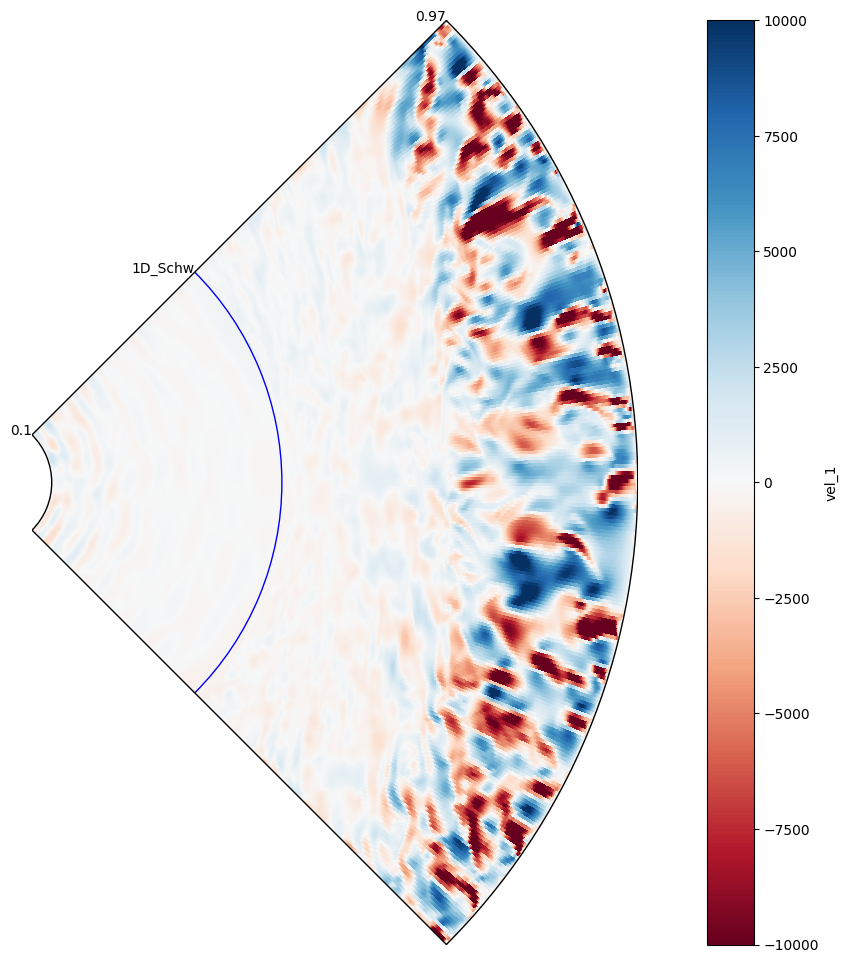

In [21]:
example_plot = cj_plotter.plot2D(t, r/r_tot, vel_1, -1e4, 1e4, cmap='RdBu') # , visible_ax=False)

example_plot.colorbar(label='vel_1')
example_plot.add_arc(r_env_init/r_tot, edgecolor='blue', label='1D_Schw')
example_plot.savefig('young_sun_Om1_vel_1.png')

## Vorticity

In [17]:
vorticity = np.genfromtxt('young_sun_25d_Om1_vorticity.csv',delimiter=',').T

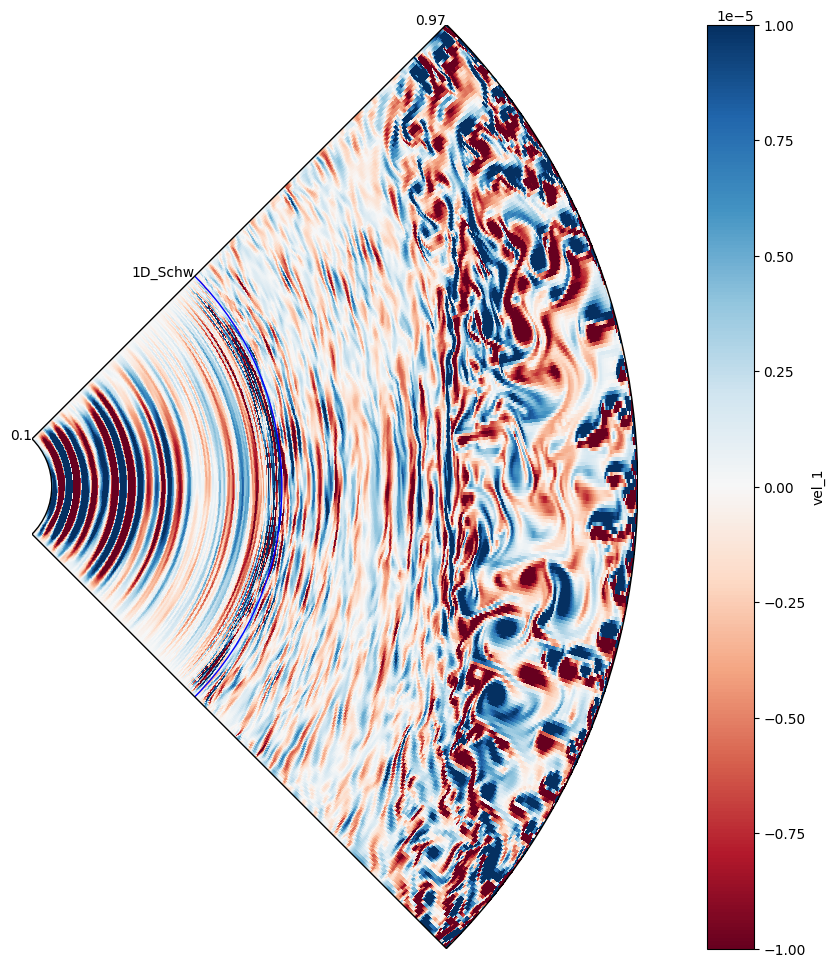

In [22]:
example_plot = cj_plotter.plot2D(t, r/r_tot, vorticity, -1e-5, 1e-5, cmap='RdBu') # , visible_ax=False)

example_plot.colorbar(label='vel_1')
example_plot.add_arc(r_env_init/r_tot, edgecolor='blue', label='1D_Schw')
example_plot.savefig('young_sun_Om1_vorticity.png')

## Temperature fluctuations

In [19]:
from music_scripts.derived_fields import temp

In [20]:
T = temp(sim[-1])

KeyError: 'abundances'